# Coffee Shop Sales — SQL + Python Analysis

**Database:** `coffee_shop.db` (SQLite) · **Tables:** `dim_stores`, `dim_products`, `fact_transactions`
**Period:** Jan 1 – Jun 30, 2023 · 3 NYC locations · 149,116 transactions

This notebook answers a set of business questions entirely with SQL run against a normalized
relational database, then uses Python to visualize the results. The raw flat transaction file
was split into a proper star schema (see `schema.sql`) before any analysis began — see the
note there on why `unit_price` lives on the fact table rather than the product dimension.

**Business question:** How should the business staff its stores, prioritize its menu, and plan
for the rest of the year, based on six months of transaction history?


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

conn = sqlite3.connect('coffee_shop.db')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10
ACCENT = '#C17F4A'
ACCENT2 = '#D9A441'


## 1. Company-wide KPIs

In [2]:
kpis = pd.read_sql('''
    SELECT
        ROUND(SUM(revenue), 2) AS total_revenue,
        COUNT(*) AS total_transactions,
        ROUND(SUM(revenue) / COUNT(*), 2) AS avg_ticket,
        SUM(transaction_qty) AS total_units
    FROM fact_transactions
''', conn)
kpis


,total_revenue,total_transactions,avg_ticket,total_units
0,698812.33,149116,4.69,214470


**Total revenue: $698,812.33** across 149,116 transactions (avg. ticket $4.69, 214,470 units sold).
This matches the Excel workbook and dashboard exactly — a useful cross-check that all three
project artifacts are built on the same source of truth.

## 2. Revenue by store — is one location carrying the business?

In [3]:
by_store = pd.read_sql('''
    SELECT s.store_location, ROUND(SUM(f.revenue), 2) AS revenue,
           COUNT(*) AS transactions, ROUND(SUM(f.revenue)/COUNT(*), 2) AS avg_ticket
    FROM fact_transactions f
    JOIN dim_stores s ON f.store_id = s.store_id
    GROUP BY s.store_location
    ORDER BY revenue DESC
''', conn)
by_store


,store_location,revenue,transactions,avg_ticket
0,Hell's Kitchen,236511.17,50735,4.66
1,Astoria,232243.91,50599,4.59
2,Lower Manhattan,230057.25,47782,4.81


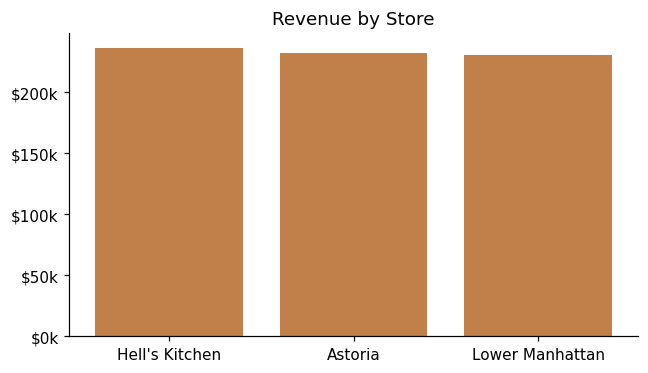

In [4]:
fig, ax = plt.subplots(figsize=(6,3.5))
ax.bar(by_store['store_location'], by_store['revenue'], color=ACCENT)
ax.set_title('Revenue by Store')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('chart_revenue_by_store.png')
plt.show()


No store is more than 1.5 points off an even three-way split of revenue. Whatever is
driving performance, it isn't location — this points toward company-wide levers (staffing
model, menu mix, hours) rather than a store-specific turnaround.

## 3. Month-over-month growth — is the upward trend real?

In [5]:
mom = pd.read_sql('''
    WITH monthly_revenue AS (
        SELECT strftime('%Y-%m', transaction_date) AS month, ROUND(SUM(revenue), 2) AS revenue
        FROM fact_transactions GROUP BY month
    )
    SELECT month, revenue,
        ROUND(revenue - LAG(revenue) OVER (ORDER BY month), 2) AS mom_change,
        ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY month))
              / LAG(revenue) OVER (ORDER BY month), 1) AS mom_pct_change
    FROM monthly_revenue ORDER BY month
''', conn)
mom


,month,revenue,mom_change,mom_pct_change
0,2023-01,81677.74,NaN,NaN
1,2023-02,76145.19,-5532.55,-6.8
2,2023-03,98834.68,22689.49,29.8
3,2023-04,118941.08,20106.40,20.3
4,2023-05,156727.76,37786.68,31.8
5,2023-06,166485.88,9758.12,6.2


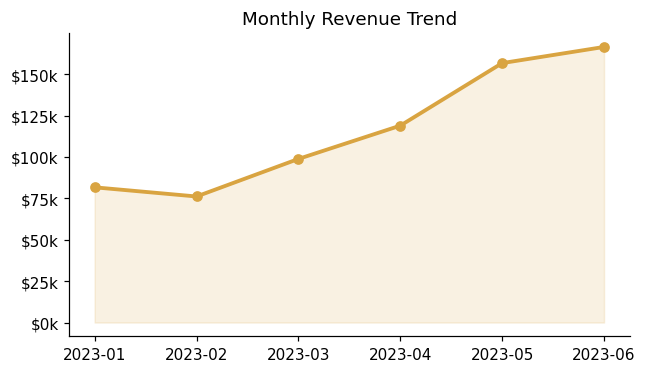

In [6]:
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(mom['month'], mom['revenue'], color=ACCENT2, marker='o', linewidth=2.5)
ax.fill_between(mom['month'], mom['revenue'], alpha=0.15, color=ACCENT2)
ax.set_title('Monthly Revenue Trend')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('chart_monthly_trend.png')
plt.show()


After a -6.8% dip from Jan to Feb, growth is positive and substantial every month after:
+29.8%, +20.3%, +31.8%, then +6.2% in June as it starts to level off. Four consecutive months
of double-digit growth is a real trend, not noise — worth validating against Q3 data once
available, since a plateau in June could mean the seasonal curve is topping out.

## 4. Top 3 products per store — does one menu fit all three locations?

In [7]:
top_products = pd.read_sql('''
    WITH product_store_rev AS (
        SELECT s.store_location, p.product_detail, p.product_category,
               SUM(f.revenue) AS revenue,
               RANK() OVER (PARTITION BY s.store_location ORDER BY SUM(f.revenue) DESC) AS rnk
        FROM fact_transactions f
        JOIN dim_stores s ON f.store_id = s.store_id
        JOIN dim_products p ON f.product_id = p.product_id
        GROUP BY s.store_location, p.product_detail, p.product_category
    )
    SELECT store_location, rnk, product_detail, product_category, ROUND(revenue,2) AS revenue
    FROM product_store_rev WHERE rnk <= 3 ORDER BY store_location, rnk
''', conn)
top_products


,store_location,rnk,product_detail,product_category,revenue
0,Astoria,1,Dark chocolate Lg,Drinking Chocolate,7897.50
1,Astoria,2,Sustainably Grown Organic Lg,Drinking Chocolate,7509.75
2,Astoria,3,Latte Rg,Coffee,6358.00
3,Hell's Kitchen,1,Civet Cat,Coffee beans,7380.00
4,Hell's Kitchen,2,Sustainably Grown Organic Lg,Drinking Chocolate,7329.25
5,Hell's Kitchen,3,Dark chocolate Lg,Drinking Chocolate,6534.00
6,Lower Manhattan,1,Dark chocolate Lg,Drinking Chocolate,6574.50
7,Lower Manhattan,2,Latte Rg,Coffee,6387.75
8,Lower Manhattan,3,Sustainably Grown Organic Lg,Drinking Chocolate,6312.75


"Dark chocolate Lg" and "Sustainably Grown Organic Lg" (coffee) are top-3 sellers at every
single store — safe to feature company-wide. But Hell's Kitchen's #1 product, "Civet Cat"
(a specialty/novelty coffee), doesn't crack the top 3 anywhere else. That's a genuine
location-specific signal — a single company-wide menu would either under-stock it at Hell's
Kitchen or waste shelf space on it elsewhere.

## 5. Revenue by hour — staffing the morning rush

Share of daily revenue from 8-10am: 36.7%


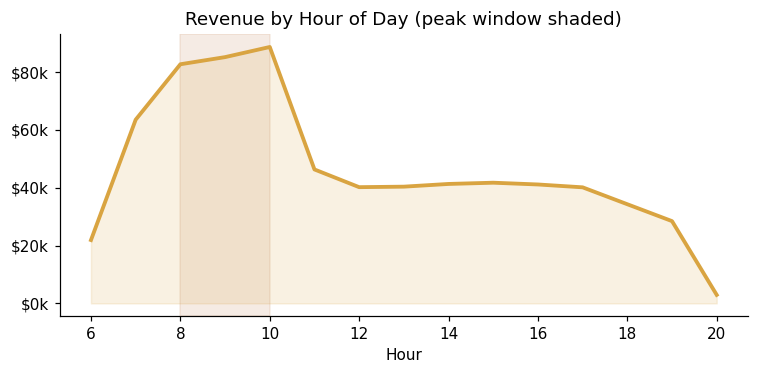

In [8]:
by_hour = pd.read_sql('''
    SELECT CAST(strftime('%H', transaction_time) AS INTEGER) AS hour,
           ROUND(SUM(revenue), 2) AS revenue, COUNT(*) AS transactions
    FROM fact_transactions GROUP BY hour ORDER BY hour
''', conn)

fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(by_hour['hour'], by_hour['revenue'], color=ACCENT2, linewidth=2.5)
ax.fill_between(by_hour['hour'], by_hour['revenue'], alpha=0.15, color=ACCENT2)
ax.axvspan(8, 10, color=ACCENT, alpha=0.15)
ax.set_title('Revenue by Hour of Day (peak window shaded)')
ax.set_xlabel('Hour')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('chart_revenue_by_hour.png')
plt.show()

peak_share = by_hour[by_hour['hour'].between(8,10)]['revenue'].sum() / by_hour['revenue'].sum()
print(f'Share of daily revenue from 8-10am: {peak_share:.1%}')


**36.7% of daily revenue happens in just 3 of ~15 operating hours (8–10am).** This is the
single clearest operational lever in the data: staffing should be heaviest in this window,
and any experiments (new menu items, faster checkout, mobile pre-order) should be piloted
here first, since it's where volume — and therefore impact — is concentrated.

## 6. Data quality check — inconsistent product pricing

In [9]:
price_issues = pd.read_sql('''
    SELECT p.product_detail, COUNT(DISTINCT f.unit_price) AS distinct_prices,
           MIN(f.unit_price) AS min_price, MAX(f.unit_price) AS max_price
    FROM fact_transactions f
    JOIN dim_products p ON f.product_id = p.product_id
    GROUP BY p.product_detail
    HAVING COUNT(DISTINCT f.unit_price) > 1
    ORDER BY (MAX(f.unit_price) - MIN(f.unit_price)) DESC
''', conn)
price_issues


,product_detail,distinct_prices,min_price,max_price
0,Organic Decaf Blend,4,12.00,28.00
1,I Need My Bean! Diner mug,2,12.00,23.00
2,I Need My Bean! Latte cup,2,14.00,23.00
3,I Need My Bean! T-shirt,2,23.00,28.00
4,Ginger Scone,3,2.65,4.06
5,Scottish Cream Scone,2,4.50,5.63
6,Jumbo Savory Scone,2,3.75,4.69
7,Chocolate Croissant,2,3.75,4.69
8,Almond Croissant,2,3.75,4.69
9,Ouro Brasileiro shot,2,2.10,3.00


15 of 80 products (nearly 1 in 5) were recorded at more than one unit price across the
six-month window — in one case ("Organic Decaf Blend") ranging from $12.00 to $28.00, more
than double. This is exactly why `unit_price` was modeled on the transaction, not the product
(see `schema.sql`): collapsing it into a single product-level price would have silently
hidden this. Before trusting any price-based analysis (discounting, margin), this should be
confirmed with the business — it may be legitimate (size variants sharing one label) or a
data entry problem worth fixing at the source.

## Summary

| Question | Answer |
|---|---|
| Is one store carrying the business? | No — revenue is split within 1.5 points across all three |
| Is the growth trend real? | Yes — 4 straight months of double-digit MoM growth (Mar–May), easing in June |
| Does one menu fit every store? | Mostly — but Hell's Kitchen has a genuine local top-seller ("Civet Cat") |
| Where should staffing focus? | 8–10am — 36.7% of daily revenue in 3 hours |
| Is the data trustworthy for pricing analysis? | Mostly, but 15 products show inconsistent unit prices — flag before using |

Full reproducible queries: `queries.sql`. Database build process: `build_db.py` + `schema.sql`.
